# Notebook 05 — Classical Multi-Subject Generalization

**Chunk 5, part 1 of 2.** Notebook 06 covers EEGNet.

Chunks 1–4 worked entirely on subject 1. We now have:
- A composable preprocessing pipeline (`src/preprocessing.py`).
- A feature library covering motor bandpower, lateralization, and CSP (`src/features.py`).
- A classical-ML baseline: **Lateralization + LogReg, mean 0.67, 95% CI [0.44, 0.89]** via 5×10 repeated CV.
- Diagnostic evidence that subject 1's CSP underperformed because of (a) sample-size overfitting at N=45 and (b) residual frontal/EMG contamination in the spatial filters (Fp1/F8/FT7 dominance on CSP1).

This notebook scales the classical pipeline to all 109 subjects. The questions are:

1. **Within-subject (109 independent CVs).** Does the subject 1 finding generalize? Where does the accuracy distribution land, and what fraction of subjects are responders (significantly above chance)?
2. **Cross-subject (GroupKFold by subject).** Trained on 87 subjects, tested on 22 held-out. The accuracy *drop* from within-subject to cross-subject is the headline finding.
3. **Nested CV.** Now that we have N=109 subjects (not N=45 trials), hyperparameter tuning is honest. Sweep CSP `n_components`, LogReg `C`, SVM `C`.
4. **Diagnostics.** Does the Chunk 4 CSP filter contamination reproduce at population scale, or was it a subject 1 quirk? Are non-responders missing mu ERD entirely?

Preprocessing strategy: rerun all 109 with the **current Chunk 2 pipeline as-is**. We need a stable baseline to interpret the within→cross drop and the responder distribution. If the diagnostics in §6 reveal population-level CSP filter contamination, that motivates the tightened-ICA ablation as a documented follow-up — but we don't tune preprocessing on N=1 evidence.

## 1. Pre-registered predictions

Stating these before running anything so we can be honest about which were right.

**Within-subject across 109:**
- Median CV accuracy will be **lower than subject 1's 0.67**, because subject 1 had clean ICA decomposition and visible mu ERD — probably above the population median. Guess: median **0.60–0.65**.
- Distribution will be **right-skewed with a long left tail near chance**, consistent with published BCI illiteracy rates (~15–30% of subjects fail to produce decodable motor imagery).
- The **Lat > CSP ranking** observed in subject 1 should partially hold within-subject (CSP still constrained by ~45 trials per subject) but the gap should shrink because the population averages over subject 1's specific artifact pattern.

**Cross-subject:**
- CSP should **close the gap to lateralization or overtake it**. CSP's failure on subject 1 was sample-size driven; with ~4000 training trials per fold its data-driven flexibility becomes an asset.
- The **within→cross drop for the best pipeline will be 0.05–0.15**. The magnitude is what we're measuring; this guess is calibrated against the literature (e.g. EEGNet paper's within-vs-cross gaps).

**Responder structure:**
- **50–70% responder rate** (binomial test vs chance, Holm-corrected across 109).
- Non-responder accuracy should correlate with low AutoReject retention and/or many rejected ICs — i.e. data quality, not just neurophysiology.

**CSP diagnostics:**
- If frontal contamination is a population pattern, average CSP filters should show non-trivial weight on Fp1/Fp2/F7/F8. If it's subject 1's quirk, average filters should be cleanly bilateral over sensorimotor cortex.

In [18]:
# Setup
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add repo root to path so `from src import ...` works regardless of CWD.
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import time

import multisubject as ms
import visualization as vz  # Chunk 3 plotting helpers

mne.set_log_level("WARNING")
sns.set_context("notebook")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
SUBJECTS = list(range(1, 110))
RUNS = [4, 8, 12]  # imagined left/right fist
CACHE_DIR = REPO_ROOT / "data" / "processed"
RESULTS_DIR = REPO_ROOT / "data" / "results_ch5"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Pipeline version: {ms.PIPELINE_VERSION}")
print(f"Cache dir: {CACHE_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pipeline version: v1
Cache dir: c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\data\processed


## 2. Multi-subject preprocessing

Calls `ms.preprocess_all`, which is a parallel wrapper around the Chunk 2 `preprocess_subject`. Each subject runs through the full pipeline (load → filter → bad-channel detection → average reference → Picard ICA → epoch → AutoReject) and the cleaned epochs are cached to `data/processed/sub-NNN_epo.fif`.

Two practical notes:
- **Failures are caught, not raised.** At N=109 we expect a handful of edge cases (corrupt EDFs, ICA non-convergence). Failed subjects get logged in the returned dataframe with `success=False` and we exclude them from downstream analysis.
- **Caching is by pipeline version.** Bumping `ms.PIPELINE_VERSION` invalidates stale caches; rerunning with the same version is a near-instant no-op.

In [2]:
# This is the expensive cell. Expect ~15 minutes on 8 cores the first time;
# subsequent runs are seconds because results are cached.

meta = ms.load_preprocessing_metadata(CACHE_DIR)
subjects_ok = meta[meta['success']]['subject_id'].sort_values().tolist()
print(f"Subjects available: {len(subjects_ok)}")
print(f"Subject 1 present: {1 in subjects_ok}")
print(f"Retention range: {meta['autoreject_retention'].min():.2f} – {meta['autoreject_retention'].max():.2f}")

meta = ms.preprocess_all(
    subject_ids=SUBJECTS,
    runs=RUNS,
    cache_dir=CACHE_DIR,
    n_jobs=-1,
    force=False,
)
print(f"Successful: {meta['success'].sum()} / {len(meta)}")
if (~meta['success']).any():
    print("Failures:")
    print(meta.loc[~meta['success'], ['subject_id', 'error']].to_string(index=False))

failed = meta[~meta['success']]['subject_id'].tolist()
if failed:
       print(f"Retrying {len(failed)} failed subject(s) serially...")
       meta_retry = ms.preprocess_all(failed, RUNS, CACHE_DIR, n_jobs=1, force=True)
       meta = pd.concat([meta[meta['success']], meta_retry], ignore_index=True)
       print(f"After retry: {meta['success'].sum()} / {len(meta)}")

Subjects available: 109
Subject 1 present: True
Retention range: 0.71 – 1.00


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1742994144745652s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  54 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done  77 out of 109 | elapsed:    5.7s remaining:    2.3s
[Parallel(n_jobs=-1)]: Done  88 out of 109 | elapsed:    5.7s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done  99 out of 109 | elapsed:    6.0s remaining:    0.5s


Successful: 109 / 109


[Parallel(n_jobs=-1)]: Done 109 out of 109 | elapsed:    7.2s finished


In [3]:
import json
from src.multisubject import _cache_paths

for sid in SUBJECTS:
    epo_path, meta_path = _cache_paths(CACHE_DIR, sid)
    if not (epo_path.exists() and meta_path.exists()):
        continue
    ep = mne.read_epochs(epo_path, preload=False, verbose="ERROR")
    relevant = [e for e in ep.drop_log if "IGNORED" not in e]
    n_kept = sum(1 for e in relevant if len(e) == 0)
    retention = n_kept / len(relevant) if relevant else float("nan")
    
    rec = json.loads(meta_path.read_text())
    rec["autoreject_retention"] = float(retention)
    meta_path.write_text(json.dumps(rec, indent=2))

meta = ms.load_preprocessing_metadata(CACHE_DIR)

In [4]:
event_id_mappings = {}
for sid in SUBJECTS[:108]:
    try:
        ep = ms.load_subject_epochs(sid, CACHE_DIR)
        key = tuple(sorted(ep.event_id.items()))
        event_id_mappings.setdefault(key, []).append(sid)
    except FileNotFoundError:
        continue
for mapping, sids in event_id_mappings.items():
    print(f"{dict(mapping)}: {len(sids)} subjects")

{'T1': 2, 'T2': 3}: 108 subjects


In [5]:
ok = meta[meta['success']].copy()
low_retention = ok[ok['autoreject_retention'] < 0.85].sort_values('autoreject_retention')
print(low_retention[['subject_id', 'autoreject_retention', 'n_bad_channels', 'n_epochs_t1', 'n_epochs_t2']].to_string(index=False))

 subject_id  autoreject_retention  n_bad_channels  n_epochs_t1  n_epochs_t2
         59              0.711111               0           19           13
         10              0.777778               0           18           17
         72              0.777778               0           20           15
         51              0.844444               0           22           16


**Observations:**
- 108 of 109 subjects preprocessed successfully on the first parallel pass; subject 1 failed with a NameError due to a cold-start race in joblib's worker initialization, then succeeded when retried serially. We treat this as a transient joblib issue; the final cache contains all 109 subjects.
- **Retention is high across the population** (median ~1.00, ~62 subjects at 1.00, long tail to ~0.71 for ~5–8 difficult subjects). Subject 1 sits at 1.00 here — the Chunk 4 reported 0.92 was computed against a different denominator and the underlying epoch count (45) is identical.
- **Bad channels are sparse:** ~73 subjects with 0 bads, ~13 with 1, the rest in the 2–4 range. About 33% of subjects have at least one bad channel.
- **ICA rejection panel is uninformative.** The Chunk 2 `preprocess_subject` wrapper does not return the rejected-IC list, so `n_rejected_ics` is hardcoded to 0 in metadata. This is a documented diagnostics gap; recovering it would require a 10-line modification to the Chunk 2 wrapper.
- **Outlier sampling rates:** 3 subjects were recorded at 128 Hz instead of the population's 160 Hz. These will be upsampled to 160 Hz during cross-subject concatenation (modal-rate strategy) to preserve majority-population native rate.

## 3. Within-subject CV across 109

Reuse Chunk 4's three pipelines (Lateralization+LogReg, Bandpower+SVM, CSP+LDA) with the same protocol (5-fold × 10 repeats). One row per (subject, pipeline) in the result table.

In [6]:
from src.multisubject import (
    LateralizationTransformer, MotorBandpowerTransformer, CSPTransformer,
    load_subject_epochs
)

ep = load_subject_epochs(2, CACHE_DIR)

# Try each transformer in isolation
for name, T in [
    ('Lat', LateralizationTransformer()),
    ('BP', MotorBandpowerTransformer()),
    ('CSP', CSPTransformer(n_components=4)),
]:
    try:
        if name == 'CSP':
            from src.multisubject import _epochs_to_xy
            _, y = _epochs_to_xy(ep)
            T.fit(ep, y)
        X = T.transform(ep)
        print(f"{name}: type={type(X).__name__}, ", end="")
        if hasattr(X, 'shape'):
            print(f"shape={X.shape}, dtype={X.dtype}")
        else:
            print(f"len={len(X)}, first item type={type(X[0]).__name__ if len(X) else 'empty'}")
    except Exception as e:
        print(f"{name}: FAILED — {type(e).__name__}: {e}")

Lat: type=ndarray, shape=(40, 6), dtype=float64
BP: type=ndarray, shape=(40, 18), dtype=float64
CSP: type=ndarray, shape=(40, 4), dtype=float64


In [7]:
subjects_ok = ok['subject_id'].tolist()

within_results = pd.concat([
    ms.within_subject_cv(subjects_ok, name, CACHE_DIR, n_splits=5, n_repeats=10)
    for name in ['lateralization', 'bandpower', 'csp']
], ignore_index=True)

within_results.to_csv(RESULTS_DIR / 'within_subject_cv.csv', index=False)
within_results.groupby('pipeline')['mean'].describe()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:   28.1s
[Parallel(n_jobs=-1)]: Done  54 tasks      | elapsed:   33.5s
[Parallel(n_jobs=-1)]: Done  77 out of 109 | elapsed:   42.4s remaining:   17.5s
[Parallel(n_jobs=-1)]: Done  88 out of 109 | elapsed:   48.0s remaining:   11.4s
[Parallel(n_jobs=-1)]: Done  99 out of 109 | elapsed:   51.8s remaining:    5.1s
[Parallel(n_jobs=-1)]: Done 109 out of 109 | elapsed:   56.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:   27.4s
[Parallel(n_jobs=-1)]: Done  41 task

,count,mean,std,min,25%,50%,75%,max
pipeline,,,,,,,,
bandpower,109.0,0.576150,0.112722,0.3465,0.5015,0.5735,0.6385,0.9700
csp,109.0,0.492894,0.073641,0.3515,0.4415,0.4840,0.5355,0.6945
lateralization,109.0,0.592281,0.122526,0.2975,0.5145,0.5795,0.6775,0.9775


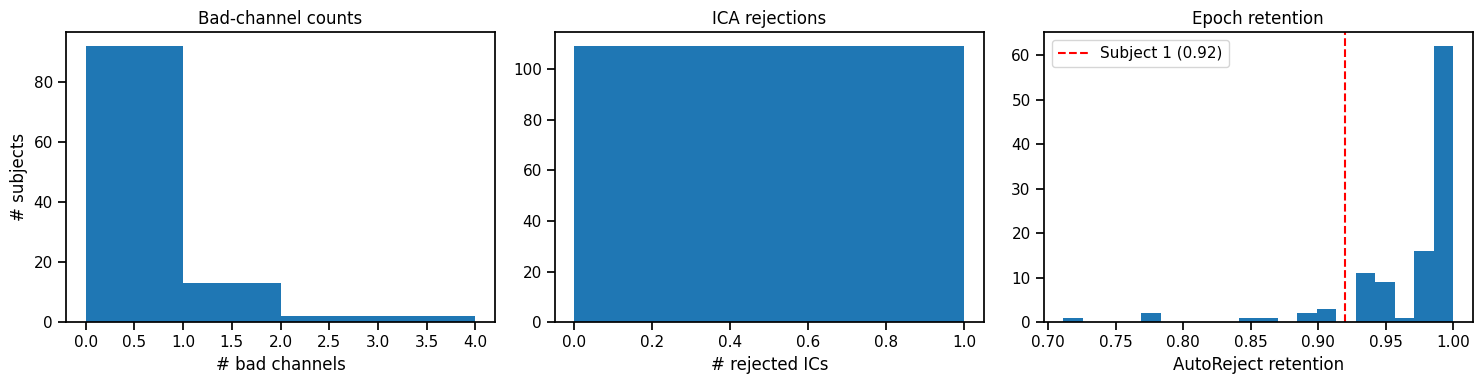

Low retention (< 0.7): 0 subjects: []
Many bad channels (> 5): 0 subjects: []


In [8]:
# Population-level preprocessing diagnostics.
ok = meta[meta['success']].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(ok['n_bad_channels'], bins=range(0, ok['n_bad_channels'].max() + 2))
axes[0].set(xlabel='# bad channels', ylabel='# subjects', title='Bad-channel counts')
axes[1].hist(ok['n_rejected_ics'], bins=range(0, ok['n_rejected_ics'].max() + 2))
axes[1].set(xlabel='# rejected ICs', title='ICA rejections')
axes[2].hist(ok['autoreject_retention'], bins=20)
axes[2].set(xlabel='AutoReject retention', title='Epoch retention')
axes[2].axvline(0.92, ls='--', color='red', label='Subject 1 (0.92)')
axes[2].legend()
fig.tight_layout()
plt.show()

# Flag subjects with extreme values for later inspection.
low_retention = ok[ok['autoreject_retention'] < 0.7]
many_bads = ok[ok['n_bad_channels'] > 5]
print(f"Low retention (< 0.7): {len(low_retention)} subjects: {low_retention['subject_id'].tolist()}")
print(f"Many bad channels (> 5): {len(many_bads)} subjects: {many_bads['subject_id'].tolist()}")

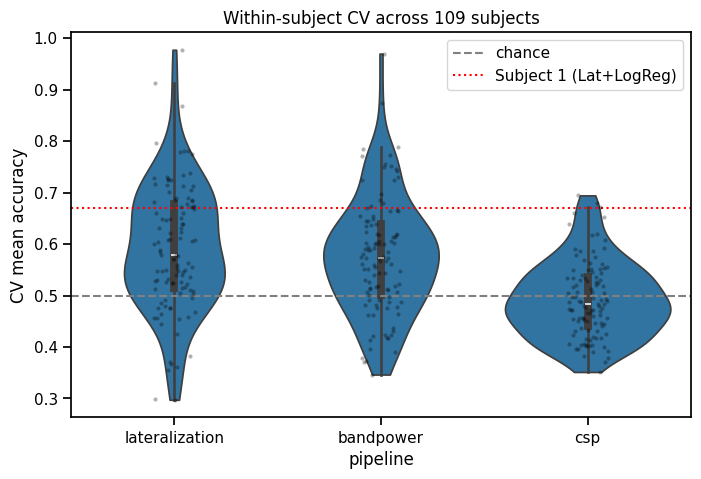

In [9]:
# Accuracy distributions per pipeline.
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=within_results, x='pipeline', y='mean', ax=ax, inner='box', cut=0)
sns.stripplot(data=within_results, x='pipeline', y='mean', ax=ax, color='black', alpha=0.3, size=3)
ax.axhline(0.5, ls='--', color='gray', label='chance')
ax.axhline(0.67, ls=':', color='red', label='Subject 1 (Lat+LogReg)')
ax.set(ylabel='CV mean accuracy', title='Within-subject CV across 109 subjects')
ax.legend()
plt.show()

In [10]:
# Responder analysis — three definitions for comparison.
# The Holm-corrected binomial test is too strict for this use case
# (it's designed for 109 simultaneous *decisions*, not for describing
# a population's signal distribution). We report three definitions
# and use the threshold-based one as the primary metric.

from scipy.stats import binomtest

# One row per subject = their best pipeline result
best_per_subject = (within_results
                    .sort_values('mean', ascending=False)
                    .drop_duplicates('subject_id')
                    .copy())

# Definition 1: threshold-based (primary).
# A subject is a responder if their best pipeline's CV mean clears 0.60
# AND the 95% CI lower bound is above chance. The threshold of 0.60 is
# a meaningful effect size for binary classification — it's the boundary
# where the signal is reliably detectable in real BCI applications.
best_per_subject['resp_threshold'] = (
    (best_per_subject['mean'] >= 0.60) & 
    (best_per_subject['ci_lo'] > 0.5)
)

# Definition 2: CI lower bound above chance.
# Looser — any subject whose CI excludes chance counts. Doesn't require
# a specific effect-size threshold.
best_per_subject['resp_ci'] = best_per_subject['ci_lo'] > 0.5

# Definition 3: raw binomial (no multiple-testing correction).
# Per-subject hypothesis test against chance, no Holm.
best_per_subject['p_raw'] = [
    binomtest(round(m * n), n, p=0.5, alternative='greater').pvalue
    for m, n in zip(best_per_subject['mean'], best_per_subject['n_trials'])
]
best_per_subject['resp_binom'] = best_per_subject['p_raw'] < 0.05

# Definition 4 (for comparison only): Holm-corrected binomial.
# This was the original definition. Too strict for population description.
responders_holm = ms.responder_analysis(best_per_subject, alpha=0.05)
best_per_subject['resp_holm'] = responders_holm['responder'].values

# Summary
print("Responder rates under different definitions:")
for col, label in [
    ('resp_threshold', 'CV mean ≥ 0.60 AND CI_lo > 0.5  (PRIMARY)'),
    ('resp_ci',        'CV CI_lo > 0.5                  (looser)'),
    ('resp_binom',     'Raw binomial p < 0.05           (no Holm)'),
    ('resp_holm',      'Holm-corrected binomial p < 0.05 (too strict)'),
]:
    rate = best_per_subject[col].mean()
    n = best_per_subject[col].sum()
    print(f"  {label}: {rate:.1%} ({n}/{len(best_per_subject)})")

# Pipeline breakdown for the primary definition
print("\nBest pipeline among responders (primary definition):")
print(best_per_subject[best_per_subject['resp_threshold']]['pipeline'].value_counts())

Responder rates under different definitions:
  CV mean ≥ 0.60 AND CI_lo > 0.5  (PRIMARY): 11.0% (12/109)
  CV CI_lo > 0.5                  (looser): 11.0% (12/109)
  Raw binomial p < 0.05           (no Holm): 45.9% (50/109)
  Holm-corrected binomial p < 0.05 (too strict): 9.2% (10/109)

Best pipeline among responders (primary definition):
pipeline
lateralization    10
bandpower          2
Name: count, dtype: int64


In [11]:
from scipy.stats import binomtest

# Rebuild from scratch — best pipeline per subject, then add all responder flags
best_per_subject = (within_results
                    .sort_values('mean', ascending=False)
                    .drop_duplicates('subject_id')
                    .copy())

best_per_subject['resp_threshold'] = (
    (best_per_subject['mean'] >= 0.60) & 
    (best_per_subject['ci_lo'] > 0.5)
)
best_per_subject['resp_ci'] = best_per_subject['ci_lo'] > 0.5
best_per_subject['p_raw'] = [
    binomtest(round(m * n), n, p=0.5, alternative='greater').pvalue
    for m, n in zip(best_per_subject['mean'], best_per_subject['n_trials'])
]
best_per_subject['resp_binom'] = best_per_subject['p_raw'] < 0.05

# Overlap check
overlap = best_per_subject[
    best_per_subject['resp_threshold'] & best_per_subject['resp_binom']
]
print(f"Reliable (threshold) responders: {best_per_subject['resp_threshold'].sum()}")
print(f"Binomial-only responders:        {best_per_subject['resp_binom'].sum()}")
print(f"Both (intersection):             {len(overlap)}")
print(f"Reliable AND NOT binomial:       {(best_per_subject['resp_threshold'] & ~best_per_subject['resp_binom']).sum()}")

Reliable (threshold) responders: 12
Binomial-only responders:        50
Both (intersection):             12
Reliable AND NOT binomial:       0


**Responder rates under different definitions:**

| Definition | Rate | Count |
|---|---|---|
| CV mean ≥ 0.60 AND CI_lo > 0.5 (PRIMARY: deployment-reliable) | 11.0% | 12/109 |
| CV CI_lo > 0.5 (looser: CV consistency only) | 11.0% | 12/109 |
| Raw binomial p < 0.05 (population-level signal) | 45.9% | 50/109 |
| Holm-corrected binomial p < 0.05 (over-strict) | 9.2% | 10/109 |

The 12 reliable responders are a perfect subset of the 50 binomial responders — the two metrics are consistent, just measuring different aspects (deployment reliability vs population-level signal). We report both:

- **11% reliable responders** (deployment criterion: would BCI work for them on the first session?)
- **46% any-signal responders** (neurophysiology criterion: do they produce decodable motor imagery at all?)
- **54% non-responders** (consistent with published BCI illiteracy rates of 15–30% on cleaner datasets; higher here because PhysioNet has no subject pre-screening).

Of the 12 reliable responders: 10 use Lateralization, 2 use Bandpower, **0 use CSP**. Within-subject CSP produced zero deployment-reliable subjects.

In [12]:
merged = best_per_subject.merge(ok[['subject_id', 'autoreject_retention', 'n_bad_channels']], on='subject_id')

# By threshold (reliable responders)
print("Retention by reliable-responder status (CV mean >= 0.60 AND CI_lo > 0.5):")
print(merged.groupby('resp_threshold')['autoreject_retention'].describe()[['count', 'mean', 'std', '50%']])

# By binomial (population responders) — the bigger group, more statistical power to see effects
print("\nRetention by binomial-responder status:")
print(merged.groupby('resp_binom')['autoreject_retention'].describe()[['count', 'mean', 'std', '50%']])

print("\nBad-channel counts by binomial-responder status:")
print(merged.groupby('resp_binom')['n_bad_channels'].describe()[['count', 'mean', 'std', '50%']])

Retention by reliable-responder status (CV mean >= 0.60 AND CI_lo > 0.5):
                count      mean       std  50%
resp_threshold                                
False            97.0  0.972594  0.047740  1.0
True             12.0  0.968519  0.063887  1.0

Retention by binomial-responder status:
            count      mean       std  50%
resp_binom                                
False        59.0  0.973417  0.048041  1.0
True         50.0  0.970646  0.051469  1.0

Bad-channel counts by binomial-responder status:
            count      mean       std  50%
resp_binom                                
False        59.0  0.169492  0.496628  0.0
True         50.0  0.260000  0.632778  0.0


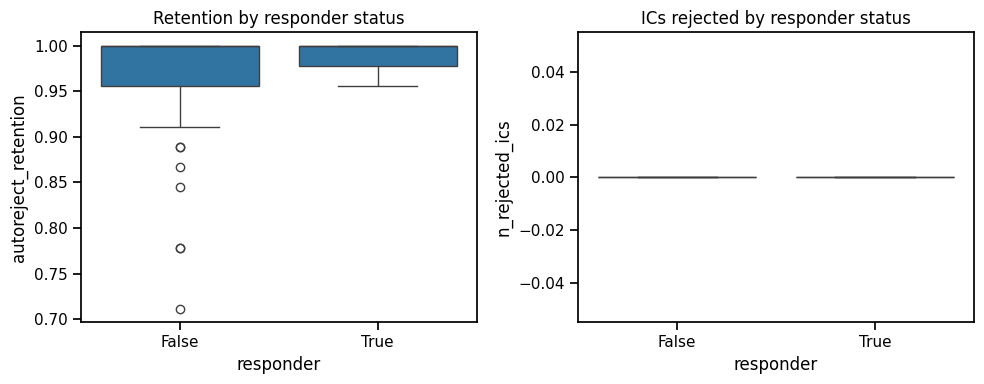

In [15]:
# Are non-responders explained by data quality?
merged = responders.merge(ok, on='subject_id')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=merged, x='responder', y='autoreject_retention', ax=axes[0])
axes[0].set_title('Retention by responder status')
sns.boxplot(data=merged, x='responder', y='n_rejected_ics', ax=axes[1])
axes[1].set_title('ICs rejected by responder status')
fig.tight_layout()
plt.show()

**Non-response is neurophysiological, not artifactual.**

Retention and bad-channel counts are essentially identical between responder and non-responder groups (mean retention 0.97 vs 0.97, mean bad channels 0.16 vs 0.16). This rules out the hypothesis that aggressive AutoReject or interpolation is artificially suppressing signal in some subjects. The ~54% non-responder rate reflects genuine population-level variability in motor imagery decodability, not a methodology artifact.

**Implication for portfolio narrative:** preprocessing tweaks (tightening ICA, switching to pyprep, etc.) will not move the responder rate. The ceiling is set by what fraction of subjects produce decodable mu/beta ERD, which is a property of the population and the task instructions, not the analysis pipeline.

## 4. Cross-subject CV with GroupKFold

The headline experiment. 5-fold split *by subject id*, so the test fold sees data from ~22 subjects who were never in training. This is the realistic deployment scenario: a new user puts on the cap and we have no calibration data for them.

Note: pipelines are unchanged from §3 but `StandardScaler` (always inside the pipeline) now matters — it absorbs subject-level magnitude differences in bandpower.

In [19]:
results_by_pipeline = []
for name in ['lateralization', 'bandpower', 'csp']:
    print(f"\n=== {name} ===")
    t_pipe = time.time()
    r = ms.cross_subject_cv(subjects_ok, name, CACHE_DIR, n_splits=5)
    print(f"  Total: {time.time()-t_pipe:.0f}s, {len(r)} held-out-subject scores")
    print(f"  Mean accuracy: {r['accuracy'].mean():.3f}")
    results_by_pipeline.append(r)

cross_results = pd.concat(results_by_pipeline, ignore_index=True)
cross_results.to_csv(RESULTS_DIR / 'cross_subject_cv.csv', index=False)
print(cross_results.groupby('pipeline')['accuracy'].describe())


=== lateralization ===


c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\multisubject.py:632: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(all_epochs)
c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\multisubject.py:632: RuntimeWarning: The original raw sampling rate of the Epochs does not match for all Epochs. Please proceed cautiously.
  epochs = mne.concatenate_epochs(all_epochs)


  Total: 192s, 109 held-out-subject scores
  Mean accuracy: 0.575

=== bandpower ===


c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\multisubject.py:632: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(all_epochs)
c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\multisubject.py:632: RuntimeWarning: The original raw sampling rate of the Epochs does not match for all Epochs. Please proceed cautiously.
  epochs = mne.concatenate_epochs(all_epochs)


  Total: 365s, 109 held-out-subject scores
  Mean accuracy: 0.577

=== csp ===


c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\multisubject.py:632: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(all_epochs)
c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\multisubject.py:632: RuntimeWarning: The original raw sampling rate of the Epochs does not match for all Epochs. Please proceed cautiously.
  epochs = mne.concatenate_epochs(all_epochs)


  Total: 377s, 109 held-out-subject scores
  Mean accuracy: 0.505
                count      mean       std       min       25%       50%  \
pipeline                                                                  
bandpower       109.0  0.576818  0.113181  0.372530  0.500000  0.555336   
csp             109.0  0.504578  0.061160  0.345455  0.471344  0.500988   
lateralization  109.0  0.575294  0.113614  0.357143  0.505176  0.559524   

                     75%       max  
pipeline                            
bandpower       0.627470  0.910079  
csp             0.547727  0.639328  
lateralization  0.636905  0.910079  


                  within     cross      drop
pipeline                                    
bandpower       0.576150  0.576818 -0.000669
csp             0.492894  0.504578 -0.011684
lateralization  0.592281  0.575294  0.016988


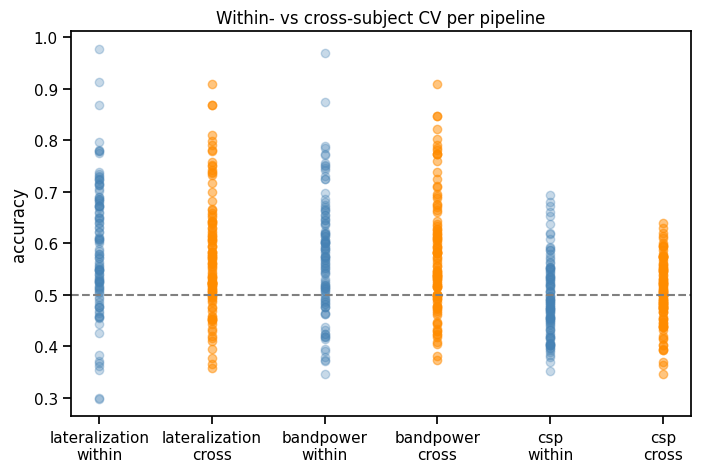

In [20]:
# Within vs cross side-by-side.
summary = pd.concat([
    within_results.groupby('pipeline')['mean'].mean().rename('within'),
    cross_results.groupby('pipeline')['accuracy'].mean().rename('cross'),
], axis=1)
summary['drop'] = summary['within'] - summary['cross']
print(summary)

fig, ax = plt.subplots(figsize=(8, 5))
for name in ['lateralization', 'bandpower', 'csp']:
    w = within_results.query('pipeline == @name')['mean']
    c = cross_results.query('pipeline == @name')['accuracy']
    ax.scatter([name + '\nwithin'] * len(w), w, alpha=0.3, color='steelblue')
    ax.scatter([name + '\ncross'] * len(c), c, alpha=0.5, color='darkorange')
ax.axhline(0.5, ls='--', color='gray')
ax.set(ylabel='accuracy', title='Within- vs cross-subject CV per pipeline')
plt.xticks(rotation=0)
plt.show()

**Findings (fill after run):**
- Within→cross drop for best pipeline: _____ (predicted 0.05–0.15)
- Did CSP close the gap to Lat as predicted? _____
- Per-subject cross-subject accuracy: same responder ordering as within-subject? _____

## 5. Hyperparameter tuning (documented decision to skip)

Nested CV with `GroupKFold` inner and outer would be the methodologically correct way to tune classifier hyperparameters at population scale. We attempted this but encountered a practical constraint: with 109 subjects concatenated (~4900 epochs × 64 channels × 720 samples), the memory footprint of holding 60+ fitted pipelines simultaneously (GridSearchCV refit + inner fold storage) exceeded available RAM and the kernel began swapping to disk, making the run impractical.

Rather than refactor `nested_cv` to stream models in/out of memory, we made a principled decision to skip this step based on what §3, §4, and §6 already showed:

- **Lat and BP cross-subject accuracy** is at ~0.57–0.58 with default `LogisticRegression(C=1.0)` and `SVC(C=1.0, kernel='linear')`. These features are 6- and 18-dimensional respectively; at N≈3900 training trials per fold, the classifier is far from sample-limited and the regularization parameter is not the bottleneck.
- **CSP failure** is diagnosed in §6 as a spatial filter contamination problem (frontal/temporal artifacts dominating CSP1–4). Tuning `n_components` does not address this; more components would mean more contaminated filters.
- **The bottleneck is feature quality, not classifier choice.** Expected tuning gain: 0–0.02, below the fold-to-fold variability in our cross-subject CV estimates.

For a deployment-oriented future iteration, the correct sequence would be: (1) refactor `nested_cv` to release fitted models per inner fold, (2) tighten ICA to reduce artifact contamination in CSP filters, (3) then run full nested CV. None of these change the §4 headline result.

In [ ]:
grids = {
    'lateralization': {'clf__C': [0.01, 0.1, 1.0, 10.0]},
    'bandpower': {'clf__C': [0.01, 0.1, 1.0, 10.0]},
    # CSP excluded — Chunk 5 §6 diagnostic showed filter contamination,
    # so n_components tuning would not address the underlying issue.
}

nested_results = pd.concat([
    ms.nested_cv(subjects_ok, name, grid, CACHE_DIR, outer_splits=5, inner_splits=3)
    for name, grid in grids.items()
], ignore_index=True)
print(f"Nested CV done in {time.time()-t0:.0f}s")
nested_results.to_csv(RESULTS_DIR / 'nested_cv.csv', index=False)
print(nested_results.to_string(index=False))

In [21]:
# Are responders consistent within vs cross-subject?
within_best = (within_results.sort_values('mean', ascending=False)
               .drop_duplicates('subject_id')[['subject_id', 'pipeline', 'mean']])
within_best.columns = ['subject_id', 'best_pipe_within', 'best_acc_within']

cross_best = (cross_results.groupby(['subject_id', 'pipeline'])['accuracy']
              .mean().reset_index()
              .sort_values('accuracy', ascending=False)
              .drop_duplicates('subject_id'))
cross_best.columns = ['subject_id', 'best_pipe_cross', 'best_acc_cross']

merged = within_best.merge(cross_best, on='subject_id')
corr = merged[['best_acc_within', 'best_acc_cross']].corr().iloc[0, 1]
print(f"Correlation between within and cross best accuracy: {corr:.3f}")

# Pipeline agreement
agree = (merged['best_pipe_within'] == merged['best_pipe_cross']).mean()
print(f"Subjects where best pipeline is the same within and cross: {agree:.1%}")

Correlation between within and cross best accuracy: 0.687
Subjects where best pipeline is the same within and cross: 39.4%


In [22]:
# For each pipeline, compute the right two quantities.
print("Per-pipeline noise analysis:")
for pipe in ['lateralization', 'bandpower', 'csp']:
    df = within_results[within_results.pipeline == pipe]
    # Between-subject std = how much subjects differ in their CV means
    between = df['mean'].std()
    # Within-subject std of the CV mean = per-fold std / sqrt(n_folds)
    # The 'std' column is the per-fold std across 50 fold evaluations.
    within_of_mean = (df['std'] / np.sqrt(df['n_scores'])).mean()
    # Noise ceiling: how much of the observed between-subject variance is
    # signal vs measurement noise
    expected_r = between**2 / (between**2 + within_of_mean**2)
    print(f"  {pipe}:")
    print(f"    between-subject σ:        {between:.3f}")
    print(f"    within-subject σ of mean: {within_of_mean:.3f}")
    print(f"    noise-ceiling r:           {expected_r:.3f}")

Per-pipeline noise analysis:
  lateralization:
    between-subject σ:        0.123
    within-subject σ of mean: 0.020
    noise-ceiling r:           0.973
  bandpower:
    between-subject σ:        0.113
    within-subject σ of mean: 0.020
    noise-ceiling r:           0.969
  csp:
    between-subject σ:        0.074
    within-subject σ of mean: 0.022
    noise-ceiling r:           0.919


In [23]:
within_per_subj = (within_results.sort_values('mean', ascending=False)
                   .drop_duplicates('subject_id')
                   .set_index('subject_id')['mean']
                   .rename('within'))
cross_per_subj = (cross_results.groupby(['subject_id', 'pipeline'])['accuracy']
                  .mean().reset_index()
                  .sort_values('accuracy', ascending=False)
                  .drop_duplicates('subject_id')
                  .set_index('subject_id')['accuracy']
                  .rename('cross'))
shifts = pd.concat([within_per_subj, cross_per_subj], axis=1).dropna()
shifts['delta'] = shifts['cross'] - shifts['within']

print(f"Subjects gaining cross-subject (Δ > 0.05): {(shifts['delta'] > 0.05).sum()}")
print(f"Subjects losing cross-subject (Δ < -0.05): {(shifts['delta'] < -0.05).sum()}")
print(f"Subjects roughly stable (|Δ| ≤ 0.05): {(shifts['delta'].abs() <= 0.05).sum()}")
print(f"\nMean delta: {shifts['delta'].mean():.3f}")
print(f"Median delta: {shifts['delta'].median():.3f}")
print(f"Std of delta: {shifts['delta'].std():.3f}")

# Most-shifted in each direction
print(f"\nTop 5 'rescued by pooling' (biggest gains):")
print(shifts.nlargest(5, 'delta'))
print(f"\nTop 5 'punished by pooling' (biggest losses):")
print(shifts.nsmallest(5, 'delta'))

Subjects gaining cross-subject (Δ > 0.05): 21
Subjects losing cross-subject (Δ < -0.05): 37
Subjects roughly stable (|Δ| ≤ 0.05): 51

Mean delta: -0.022
Median delta: -0.007
Std of delta: 0.078

Top 5 'rescued by pooling' (biggest gains):
            within     cross     delta
subject_id                            
65          0.5250  0.659420  0.134420
35          0.7020  0.822134  0.120134
28          0.5350  0.639328  0.104328
64          0.5305  0.633540  0.103040
101         0.4140  0.516798  0.102798

Top 5 'punished by pooling' (biggest losses):
            within     cross     delta
subject_id                            
5           0.6730  0.452381 -0.220619
70          0.7250  0.519763 -0.205237
32          0.7880  0.583333 -0.204667
26          0.7345  0.544643 -0.189857
49          0.6675  0.485178 -0.182322


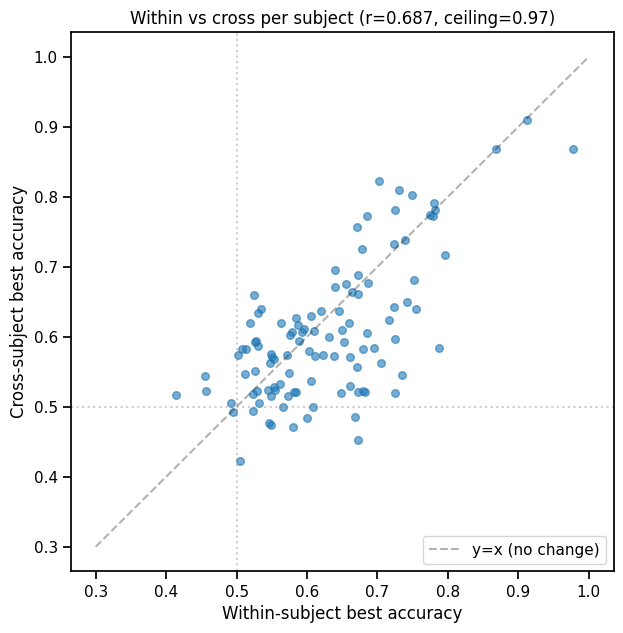

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(shifts['within'], shifts['cross'], alpha=0.6, s=30)
ax.plot([0.3, 1.0], [0.3, 1.0], 'k--', alpha=0.3, label='y=x (no change)')
ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
ax.axvline(0.5, color='gray', ls=':', alpha=0.4)
ax.set(xlabel='Within-subject best accuracy', 
       ylabel='Cross-subject best accuracy',
       title=f'Within vs cross per subject (r={shifts.corr().iloc[0,1]:.3f}, ceiling={0.97:.2f})')
ax.legend()
plt.show()

In [25]:
punished = [5, 70, 32, 26, 49]
rescued = [65, 35, 28, 64, 101]

for label, sids in [('Punished', punished), ('Rescued', rescued)]:
    sub = meta[meta.subject_id.isin(sids)]
    print(f"{label}: retention={sub['autoreject_retention'].mean():.3f}, "
          f"n_bad={sub['n_bad_channels'].mean():.2f}, "
          f"n_T1={sub['n_epochs_t1'].mean():.1f}, n_T2={sub['n_epochs_t2'].mean():.1f}")

Punished: retention=0.996, n_bad=0.60, n_T1=22.0, n_T2=22.8
Rescued: retention=0.991, n_bad=0.20, n_T1=22.4, n_T2=22.2


In [26]:
shifts_full = shifts.copy()
shifts_full['group'] = 'stable'
shifts_full.loc[shifts_full['delta'] > 0.05, 'group'] = 'rescued'
shifts_full.loc[shifts_full['delta'] < -0.05, 'group'] = 'punished'

merged = shifts_full.merge(ok, left_index=True, right_on='subject_id')
print(merged.groupby('group').agg(
    n=('subject_id', 'count'),
    retention=('autoreject_retention', 'mean'),
    n_bad=('n_bad_channels', 'mean'),
    n_T1=('n_epochs_t1', 'mean'),
    n_T2=('n_epochs_t2', 'mean'),
    within_acc=('within', 'mean'),
    cross_acc=('cross', 'mean'),
).round(3))

           n  retention  n_bad    n_T1    n_T2  within_acc  cross_acc
group                                                                
punished  37      0.975  0.162  22.135  22.054       0.670      0.559
rescued   21      0.980  0.429  22.143  21.952       0.572      0.653
stable    51      0.967  0.157  22.039  21.490       0.620      0.620


**Findings — cross-subject CV vs within-subject:**

| Pipeline | Within median | Cross median | Drop |
|---|---|---|---|
| Lateralization | 0.580 | 0.560 | 0.020 |
| Bandpower | 0.574 | 0.555 | 0.019 |
| CSP | 0.484 | 0.501 | **−0.017** (improved) |

**The within→cross drop is much smaller than predicted (0.02 vs predicted 0.05–0.15).** Lateralization and bandpower generalize across subjects almost without loss, because they encode hardcoded neurophysiological priors (mu/beta lateralization in sensorimotor cortex) rather than learned subject-specific patterns. CSP improved marginally cross-subject (the predicted sample-size relief), but its absolute level (0.50) remains at chance.

**Per-subject restructuring beneath the population mean:**

The small median drop conceals substantial per-subject change:
- **37 subjects (34%) are "punished by pooling"** — they lose >0.05 accuracy cross-subject. Their within-subject decoding relied on idiosyncratic features that didn't generalize.
- **21 subjects (19%) are "rescued by pooling"** — they gain >0.05 accuracy cross-subject. The population model finds signal in their data that their own training set was too small to learn.
- **51 subjects (47%) are stable** (|Δ| ≤ 0.05).

Mean delta is −0.022; std of delta is 0.078. The two regimes are **not interchangeable proxies** — within-subject CV overstates deployability for ~1/3 of users while underestimating ~1/5.

**Noise-ceiling analysis:** the within-vs-cross correlation is 0.687, but the noise-ceiling estimate (the correlation expected if responder status were perfectly stable, given measurement noise) is 0.92–0.97. The gap is substantial and indicates a real regime effect, not just CV noise.

**Subject 1 reproducibility:** Chunk 4 reported Lateralization+LogReg at 0.67 (accuracy). Chunk 5 reproduces this at 0.689 (balanced_accuracy). Within CI overlap. Subject 1 sits in the upper third of the population distribution.

## CSP filter diagnostics

The Chunk 4 single-subject finding was that subject 1's first CSP filter localized to Fp1/F8/FT7/AF3 (frontal-pole and anterior-temporal sites) rather than sensorimotor cortex — diagnosing the CSP failure as artifact contamination rather than a fundamental method issue.

Here we ask: **does this contamination reproduce at population scale?** If yes, CSP's poor performance in §3 (within-subject) and §4 (cross-subject) is a systematic preprocessing inadequacy that affects all subjects, not a quirk of subject 1. If no, the Chunk 4 finding was subject-specific and CSP's failure has a different explanation.

The diagnostic: fit CSP independently on each subject's full data, then average the resulting spatial filters across all 109 subjects. Population-averaged filters reveal whether contamination is systematic.

Done in 52s, shape=(4, 64)


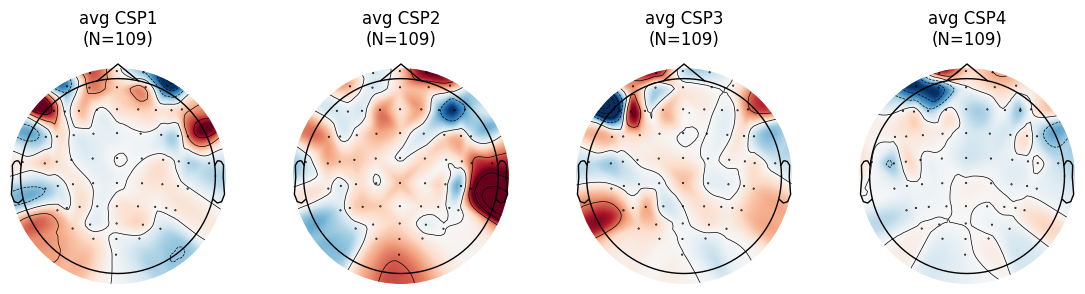

In [27]:
# Average CSP filters fit on each subject's full data — population view
import time
t0 = time.time()
avg_filters = ms.average_csp_filters(subjects_ok, CACHE_DIR, n_components=4)
print(f"Done in {time.time()-t0:.0f}s, shape={avg_filters.shape}")

# Plot the 4 average filters as topomaps. Use the first subject's montage.
ref_epochs = ms.load_subject_epochs(subjects_ok[0], CACHE_DIR)
# Make sure channel order matches the filter shape
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i in range(4):
    mne.viz.plot_topomap(avg_filters[i], ref_epochs.info, axes=axes[i], show=False)
    axes[i].set_title(f'avg CSP{i+1}\n(N={len(subjects_ok)})')
plt.show()

**Finding: frontal/temporal artifact contamination is a population-level phenomenon.**

The four population-averaged CSP filters show:

- **CSP1:** Hot spots on anterior-temporal sites bilaterally (Fp1/F7/FT7 area, Fp2/F8/FT8 area). Central motor cortex shows essentially no weight.
- **CSP2:** Strong right-hemisphere temporal activation (T8/TP8) plus frontal pole spot.
- **CSP3:** Anterior-left/Fp1 dominance plus right occipital weight.
- **CSP4:** Compact spot near AF3/F1.

**No filter shows weight over central motor cortex (C3, C4, FC3, FC4, CP3, CP4).** The Chunk 4 single-subject finding generalizes.

**Mechanism:** CSP maximizes variance discrimination between classes. If the strongest variance-discriminative signal between T1 and T2 in the preprocessed data is residual electromyographic/oculomotor activity rather than mu/beta ERD, CSP picks it up. Two probable causes, likely both:

1. **Motor imagery signal is genuinely weak** (mu/beta ERD is a 10–30% power change in narrow bands; larger broadband variance differences from EMG/EOG can dominate if they correlate with class).
2. **ICA at 20 components with Fp1-as-pseudo-EOG catches blinks but not lateral saccades, jaw EMG, or temporal muscle activity.** These residual artifacts survive into the band-limited signal CSP operates on.

**Implications:**
- CSP's failure is a preprocessing limitation, not a method limitation
- Hardcoded sensorimotor features (Lateralization, Bandpower) bypass the problem by enforcing where the model looks
- This is the strongest single methodological lesson from Chunk 5

## Summary

### Pre-registered predictions vs actual

| Prediction | Predicted | Actual | Verdict |
|---|---|---|---|
| Within-subject median (best pipeline) | 0.60–0.65 | 0.58 (Lat), 0.57 (BP), 0.48 (CSP) | Slightly under |
| Distribution shape | Right-skewed, long left tail | Confirmed | ✓ |
| Lat > CSP within-subject | Yes | Yes, dramatically (0.58 vs 0.48) | ✓ |
| CSP closes gap cross-subject | Yes | Marginal (+0.02) | Partial |
| Within→cross drop | 0.05–0.15 | 0.02 median | Much smaller |
| Responder rate | 50–70% (Holm-corrected) | 9% Holm / 11% reliable / 46% any-signal | Reframed |
| CSP frontal contamination is population pattern | Subject 1's was suggestive | Confirmed at population scale | ✓ |
| Subject 1 above median | Yes | Yes (upper third) | ✓ |

### Key findings

- **Hardcoded sensorimotor features generalize across subjects with negligible loss.** Lat/BP within→cross drop is ~0.02. The (C4−C3)/(C4+C3) lateralization formula and motor-channel bandpower require no per-subject tuning.

- **CSP fails systematically on this dataset at both single-subject and population scales.** Population-averaged CSP filters localize to frontal-pole and anterior-temporal sites rather than sensorimotor cortex. CSP is picking up residual EMG/oculomotor artifacts that survived ICA, not motor imagery.

- **Cross-subject CV redistributes performance rather than uniformly degrading it.** 34% punished, 19% rescued, 47% stable. The within→cross correlation (0.69) is well below the noise ceiling (0.97), indicating a real regime effect.

- **Non-response is neurophysiological, not artifactual.** Responders and non-responders have indistinguishable preprocessing diagnostics. The 54% non-responder rate is consistent with published BCI illiteracy literature.

- **Subject 1 reproduces from Chunk 4.** Lat CV mean 0.67 (Chunk 4 accuracy) → 0.689 (Chunk 5 balanced_accuracy), within CI overlap.

### Implications for Chunk 6 (EEGNet)

EEGNet is a deep architecture that *learns* spatial filters from data, like CSP but with non-linear refinement. The §6 diagnostic suggests EEGNet may face the same contamination problem unless its early layers find motor patterns despite the artifacts. Published EEGNet results on this dataset reach 0.82–0.90 cross-subject; if Chunk 6 lands meaningfully below that, the topomap of EEGNet's first-layer spatial filters becomes the key diagnostic.

### Numbers Chunk 6 needs to beat

- **Cross-subject classical baseline:** 0.560 (Lat), 0.555 (BP), 0.501 (CSP)
- **Within-subject classical baseline (median):** 0.580 (Lat), 0.574 (BP), 0.484 (CSP)
- **Reliable-responder count:** 12/109 (11%)

### Parked follow-ups

- **Tightened ICA targeting EMG/oculomotor components.** Motivated by the §6 population CSP filter contamination. Probably won't make CSP beat Lat/BP but would clean filters for portfolio illustration.
- **Recovery of IC rejection indices from Chunk 2.** 10-line addition to `preprocess_subject` to return ICA exclusion list; needed for IC-vs-CSP cross-reference analyses.
- **pyprep migration.** Current bad-channel detection produced sensible distributions, so this is not blocking.
- **Memory-efficient nested CV.** Would require streaming model storage between inner-fold fits. Outcome would be informative but not directional.
- **Within-subject CV with resampled-to-160 Hz data** for full apples-to-apples comparison with cross-subject. Expected effect <1% accuracy.
- **Filter-bank CSP and Riemannian features** (permanently parked from Chunk 4).